In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
# import word2number

In [2]:
# Example usage
# number = w2n.word_to_num("two hundred and thirty four")
# print(number)  # Output: 234

In [4]:
# conda install conda-forge::word2number

In [16]:
df = pd.read_csv("hiring.csv")

In [17]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [10]:
#df['test_score(out of 10)'].mean()

In [18]:
df = df.fillna({'experience': 'zero', 'test_score(out of 10)': 8.0})

In [19]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,8.0,7,72000
7,eleven,7.0,8,80000


In [23]:
def convert_word_to_number(word):
    word_dict = {
        'zero': 0, 'one': 1, 'two': 2, 'three': 3, 'four': 4, 
        'five': 5, 'six': 6, 'seven': 7, 'eight': 8, 'nine': 9,
        'ten': 10, 'eleven': 11
    }
    
    if isinstance(word, (int, float)):
        return word
    
    word = word.lower().strip()
    
    # Check if it's a simple word in our dictionary
    if word in word_dict:
        return word_dict[word]
    
    # Handle compound words (like twenty-one or twenty one)
    if '-' in word:
        parts = word.split('-')
    else:
        parts = word.split()
    
    # Simple case for two-part numbers (e.g., twenty-one)
    if len(parts) == 2:
        if parts[0] in word_dict and parts[1] in word_dict:
            return word_dict[parts[0]] + word_dict[parts[1]]
    
    # If not recognized, return original value or handle as needed
    try:
        # Try to convert if it's already a numeric string
        return float(word) if '.' in word else int(word)
    except ValueError:
        return word  # or return some default value

# Apply the function to the DataFrame column
df.experience = df.experience.apply(convert_word_to_number)

In [25]:
import math 
median_test_score = math.floor(df['test_score(out of 10)'].mean())
median_test_score

7

In [26]:
df = df.rename(columns={'salary($)': 'salary'})

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   experience                  8 non-null      int64  
 1   test_score(out of 10)       8 non-null      float64
 2   interview_score(out of 10)  8 non-null      int64  
 3   salary                      8 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 388.0 bytes


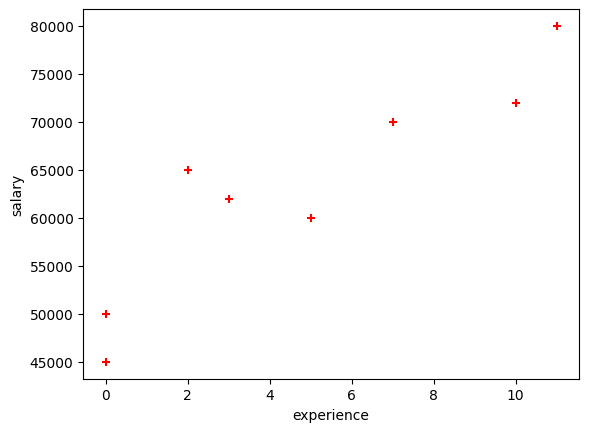

In [35]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.xlabel('experience')
plt.ylabel('salary')
plt.scatter(df.experience, df.salary, color='red',marker='+')
plt.show()

In [37]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


In [36]:
reg = linear_model.LinearRegression()
reg.fit(df[['experience','test_score(out of 10)','interview_score(out of 10)']], df['salary'])

LinearRegression()

In [60]:
reg.predict([[2, 9.3, 6]])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([53759.6797671])

In [66]:
reg.predict([[12, 11, 10]])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([93847.88937409])

### Desired Results

In [68]:
desired_result = [ 53713.86677124], [ 93747.79628651]

### Closest Results Obtained

In [69]:
result_obtained = [53759.6797671], [93847.88937409]